In [435]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [436]:
# Load data  
df = pd.read_csv("unicef_malawi.csv")
df.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
0,1.0,2.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,YES,NO
1,1.0,3.0,1.0,1.0,5.0,YES,ECE,NaN,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,YES
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
3,1.0,8.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO
4,1.0,10.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,8.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO


In [437]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13059 non-null  float64
 5   CB4         13059 non-null  object 
 6   CB5A        12203 non-null  object 
 7   CB5B        11575 non-null  object 
 8   CB7         12203 non-null  object 
 9   CB11        13059 non-null  object 
 10  CL3         4159 non-null   float64
 11  CL13        11092 non-null  object 
 12  FCD2A       11264 non-null  object 
 13  FCD2B       11264 non-null  object 
 14  FCD2C       11264 non-null  object 
 15  FCD2D       11264 non-null  object 
 16  FCD2E       11264 non-null  object 
 17  FCD2F       11264 non-null  object 
 18  FCD2G       11264 non-null  object 
 19  FCD2H       11264 non-nul

### 0. First tidy up NaNs, because couldn't split the data with NaNs
strategy: checking all the data inputs and ratio of NaN values in the dataset

In [438]:
print(f"Total NaNs: {df.isnull().sum().sum()}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum()}")
print(f"Total NO \"RESPONSE\": {(df == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df[df == "NO RESPONSE"].any(axis=1).sum()}")


Total NaNs: 71374
Rows with any NaN: 12458
Total NO "RESPONSE": 1293
Rows with any "NO RESPONSE": 1121


In [439]:
df[df.isin(['NO RESPONSE']).any(axis=1)]

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
16,2.0,4.0,2.0,2.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,YES,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,NaN
31,3.0,17.0,2.0,2.0,8.0,YES,PRIMARY,CLASS/YEAR/GRADE 3,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,NO,NO
39,4.0,5.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,DUG WELL: PROTECTED WELL,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
67,6.0,14.0,2.0,2.0,7.0,YES,PRIMARY,CLASS/YEAR/GRADE 1,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,25.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13026,1101.0,4.0,1.0,1.0,14.0,YES,PRIMARY,CLASS/YEAR/GRADE 5,YES,NO RESPONSE,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,90.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NO
13100,1107.0,4.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,YES,YES,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,10.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13124,1109.0,1.0,1.0,1.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,NO,TUBE WELL / BOREHOLE,ELSEWHERE,150.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13127,1109.0,7.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,NO,NO,DUG WELL: UNPROTECTED WELL,NO RESPONSE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,YES


_Significantly more NaNs than expected!_\
_Not only do we have a couple of columns with a high number of NaNs (HW5,FCD5, CL3(!!)), but also 12458 / 13162 rows have at least 1 missing vaulue -> can't just delete rows with missing values as we'd have a fraction of the dataset left._

In [440]:
df = df.fillna('NO RESPONSE')

In [441]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13162 non-null  object 
 5   CB4         13162 non-null  object 
 6   CB5A        13162 non-null  object 
 7   CB5B        13162 non-null  object 
 8   CB7         13162 non-null  object 
 9   CB11        13162 non-null  object 
 10  CL3         13162 non-null  object 
 11  CL13        13162 non-null  object 
 12  FCD2A       13162 non-null  object 
 13  FCD2B       13162 non-null  object 
 14  FCD2C       13162 non-null  object 
 15  FCD2D       13162 non-null  object 
 16  FCD2E       13162 non-null  object 
 17  FCD2F       13162 non-null  object 
 18  FCD2G       13162 non-null  object 
 19  FCD2H       13162 non-nul

Filled with "NO RESPONSE" globally to split into test/training. More data investigation after the split

In [442]:
X = df.drop(columns=['FCF26']) 
y = df['FCF26']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=8, ## fixing the state for reproducibility
    stratify=y      ## to guarantee balanced split of data
)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

<Axes: >

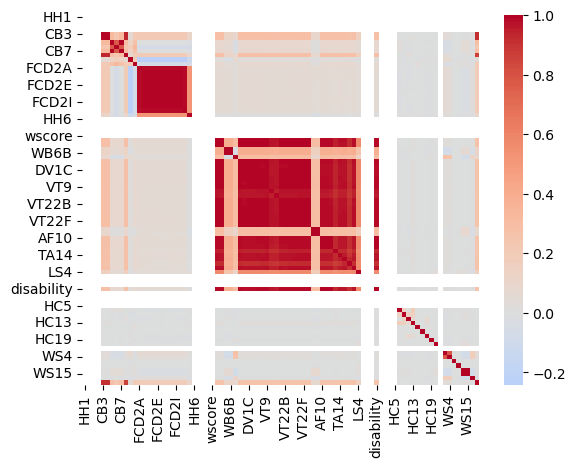

In [443]:
no_response_matrix = (df_train == 'NO RESPONSE').astype(int)
no_response_corr = no_response_matrix.corr()
sns.heatmap(no_response_corr, cmap='coolwarm', center=0, annot=False)

#### 0.1 checking if there is any reason for the missing data (Child Labour subset)

In [444]:
cols = ['CL2','CL3', 'CL12', 'CL13', 'FCF26']
df_train[df_train['CL3'].isin(['NO RESPONSE'])][cols]

,CL2,CL3,CL12,CL13,FCF26
773,False,NO RESPONSE,True,1.0,A FEW TIMES A YEAR
2464,False,NO RESPONSE,True,4.0,MONTHLY
9916,False,NO RESPONSE,False,NO RESPONSE,NO RESPONSE
5113,False,NO RESPONSE,True,0.0,A FEW TIMES A YEAR
10868,False,NO RESPONSE,True,0.0,A FEW TIMES A YEAR
...,...,...,...,...,...
6910,False,NO RESPONSE,False,NO RESPONSE,NEVER
295,False,NO RESPONSE,True,3.0,MONTHLY
2558,False,NO RESPONSE,True,3.0,A FEW TIMES A YEAR
6331,False,NO RESPONSE,True,30.0,NEVER


In [445]:
## check how False / True translates to CL2
df_train[df_train['CL3'] == 'NO RESPONSE']['CL2'].value_counts(normalize=True)

CL2
False    1.0
Name: proportion, dtype: float64

_Conclusion: whereever CL2 is False (Child Labour = False), there's a missing CL3 value. This means, all CL3 NaNs can be made 0, as the child is NOT working = 0 working hours._

In [446]:
df_train.CL3.unique()

array(['NO RESPONSE', 3.0, 1.0, 20.0, 0.0, 28.0, 6.0, 2.0, 5.0, 4.0, 12.0,
       10.0, 14.0, 13.0, 7.0, 36.0, 9.0, 11.0, 8.0, 40.0, 23.0, 30.0,
       15.0, 21.0, 42.0, 18.0, 63.0, 77.0, 60.0, 27.0, 26.0, 24.0, 56.0,
       16.0, 25.0, 35.0, 43.0, 22.0, 32.0, 49.0, 70.0, 66.0, 45.0, 55.0,
       72.0, 17.0], dtype=object)

In [447]:
df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_81630/2669409082.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_81630/2669409082.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)


In [448]:
df_train[df_train['CL13'] == 'NO RESPONSE']['CL12'].value_counts(normalize=True)

CL12
False    0.997586
True     0.002414
Name: proportion, dtype: float64

In [449]:
df_train.CL13.unique()

array(['1.0', '6.0', '4.0', '16.0', 'NO RESPONSE', '0.0', '25.0', '5.0',
       '20.0', '14.0', '2.0', '8.0', '3.0', '10.0', '30.0', '7.0', '11.0',
       '15.0', '17.0', '48.0', '9.0', '44.0', '13.0', '23.0', '12.0',
       '39.0', '22.0', '40.0', '35.0', '42.0', '18.0', '21.0', '28.0',
       '19.0', '24.0', '43.0', '60.0', '50.0', '45.0', '51.0', '26.0',
       '34.0', '29.0', '33.0', '32.0', '66.0', '54.0', '31.0', '56.0',
       '72.0', '55.0'], dtype=object)

_99.8% of data for CL13 and CL12 follow the same rule -> make CL13 0.0_

In [450]:
df_train['CL13'] = df_train['CL13'].replace('NO RESPONSE', 0.0)
df_test['CL13'] = df_test['CL13'].replace('NO RESPONSE', 0.0)

In [451]:
print(f"Total NO \"RESPONSE\": {(df_train == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df_train[df_train == "NO RESPONSE"].any(axis=1).sum()}")

Total NO "RESPONSE": 49645
Rows with any "NO RESPONSE": 8877


In [452]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD5         4019
HW5          2798
MA3          2432
MA2          2408
WB14         2358
             ... 
HH6             0
HH7             0
HL4             0
ethnicity       0
HH1             0
Length: 87, dtype: int64

FCD5. _Do you believe that in order to bring up, raise, or educate a child properly, the child needs to be physically punished?_\
checing correlation with other FCD columns

FCD2A-K are different types of physical punishment methods

In [453]:
fcd_cols = ['FCD5','FCD2A','FCD2B', 'FCD2C',
'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']
df_train[df_train['FCD5'] == 'NO RESPONSE'][fcd_cols + ['FCF26']]

,FCD5,FCD2A,FCD2B,FCD2C,FCD2D,FCD2E,FCD2F,FCD2G,FCD2H,FCD2I,FCD2J,FCD2K,FCF26
773,NO RESPONSE,NO,YES,NO,YES,YES,NO,NO,NO,NO,NO,NO,A FEW TIMES A YEAR
2464,NO RESPONSE,NO,YES,NO,YES,YES,NO,NO,YES,NO,NO,NO,MONTHLY
11506,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,WEEKLY
9916,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE
7909,NO RESPONSE,YES,YES,NO,YES,YES,NO,NO,NO,NO,NO,NO,NEVER
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
2558,NO RESPONSE,YES,YES,NO,YES,YES,YES,YES,YES,NO,NO,NO,A FEW TIMES A YEAR
5304,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
6331,NO RESPONSE,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,NO,NEVER


In [454]:
df_train[df_train['FCD2K'] == 'NO RESPONSE'][fcd_cols].value_counts(normalize=True)

FCD5         FCD2A        FCD2B        FCD2C        FCD2D        FCD2E        FCD2F        FCD2G        FCD2H        FCD2I        FCD2J        FCD2K      
NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE    0.985788
NO           NO           NO           NO           NO           NO           NO           NO           NO           NO           NO           NO RESPONSE    0.000646
NO RESPONSE  NO           YES          NO           NO           NO           NO           NO           NO           NO           NO           NO RESPONSE    0.000646
YES          NO           YES          NO           YES          YES          NO           NO           YES          YES          NO           NO RESPONSE    0.000646
NO RESPONSE  YES          YES          YES          YES          NO           YES          NO           YES          NO           NO           NO RESPONSE    0.000646
          

<Axes: >

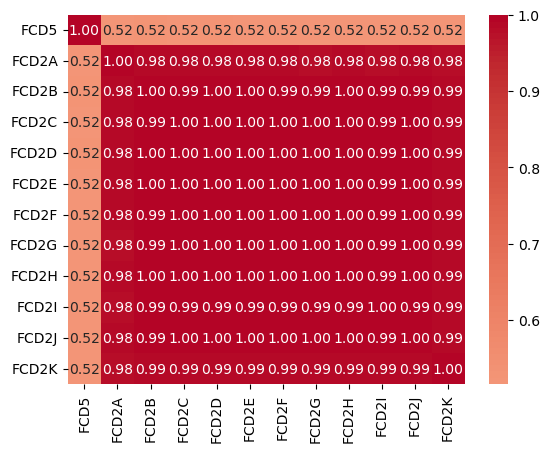

In [455]:
fcd_no_resp = (df_train[fcd_cols] == 'NO RESPONSE').astype(int)
sns.heatmap(fcd_no_resp.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')

_Conclusion: If there is missing data for one Physical punishment type (FCD2) column, it is missing in almost all the other FCD2X ones -> it looks like an intentional skip, but we can't quite tell if it's missed because a person doesn't want to disclose what kind of punishment they use OR they don't agree with punishment. First step: if FCD2 columns are ALL "NO", make FCD5 "NO RESPONSE" a "NO" too. If there's any "YES" make it a "YES"._

In [456]:
fcd2_cols = ['FCD2A','FCD2B', 'FCD2C',
'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']

for df in [df_train, df_test]:
    mask = df['FCD5'].isin(['NO RESPONSE', 'DK / NO OPINION'])
    
    any_yes = df.loc[mask, fcd2_cols].isin(['YES']).any(axis=1)
    df.loc[mask & any_yes, 'FCD5'] = 'YES'
    
    all_no = (df.loc[mask, fcd2_cols] == 'NO').all(axis=1)
    df.loc[mask & all_no, 'FCD5'] = 'NO'

In [457]:
df_train['FCD5'].value_counts()

FCD5
NO             5453
YES            3547
NO RESPONSE    1529
Name: count, dtype: int64

In [458]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5          2798
MA3          2432
MA2          2408
WB14         2358
FCD2A        1565
             ... 
HH6             0
HH7             0
HL4             0
ethnicity       0
HH1             0
Length: 87, dtype: int64

HW5. _Do you have any soap or detergent or ash/mud/sand in your house for washing hands?_
MA2. How old is your (husband/partner)?
Probe: How old was your (husband/partner) on his last birthday?

MA3. Besides yourself, does your (husband/partner) have any other wives or partners or does he live with other women as if married?

In [459]:
top_NaNs_cols = ['HW5','MA3', 'MA2']
df_train[df_train['MA2'] == 'NO RESPONSE'][top_NaNs_cols + ['FCF26']]

,HW5,MA3,MA2,FCF26
11506,NO,NO RESPONSE,NO RESPONSE,WEEKLY
9916,NO,NO RESPONSE,NO RESPONSE,NO RESPONSE
7909,YES,NO RESPONSE,NO RESPONSE,NEVER
9934,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
12931,YES,NO RESPONSE,NO RESPONSE,WEEKLY
...,...,...,...,...
8465,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
10276,YES,NO RESPONSE,NO RESPONSE,MONTHLY
8734,YES,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
8307,NO,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR


MA2 and MA3 perfect correlation — likely no husband -> leaving as "NO RESPONSE"

WB5. _Have you ever attended school or any early childhood education programme?_

WB6. _What is the highest level and grade or year of school you have attended?_

In [460]:
top_NaNs_cols = ['HW5','WB14', 'WB5', 'WB6B', 'WB6A']
df_train[df_train['WB14'] == 'NO RESPONSE'][top_NaNs_cols + ['FCF26']]

,HW5,WB14,WB5,WB6B,WB6A,FCF26
2464,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,HIGHER,MONTHLY
11506,NO,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,WEEKLY
9916,NO,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE
9934,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
1377,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 3,UPPER SECONDARY,NEVER
...,...,...,...,...,...,...
12800,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
5578,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,A FEW TIMES A YEAR
9431,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,A FEW TIMES A YEAR
2777,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,LOWER SECONDARY,NEVER


In [461]:
print(df_train['WB5'].value_counts(normalize=True))
print(df_train['WB6A'].value_counts(normalize=True))
print(df_train['WB6B'].value_counts(normalize=True))
print(df_train['WB14'].value_counts(normalize=True))

WB5
YES            0.855637
NO             0.118530
NO RESPONSE    0.025833
Name: proportion, dtype: float64
WB6A
PRIMARY                0.656663
NO RESPONSE            0.144363
LOWER SECONDARY        0.095641
UPPER SECONDARY        0.083674
HIGHER                 0.017760
VOCATIONAL TRAINING    0.001520
ECE                    0.000380
Name: proportion, dtype: float64
WB6B
NO RESPONSE           0.144743
CLASS/GRADE 8         0.142844
CLASS/YEAR/GRADE 4    0.140754
CLASS/YEAR/GRADE 2    0.123943
CLASS/GRADE 7         0.106753
CLASS/YEAR/GRADE 3    0.098490
CLASS/YEAR/GRADE 5    0.096115
CLASS/GRADE 6         0.084149
CLASS/YEAR/GRADE 1    0.062114
DK                    0.000095
Name: proportion, dtype: float64
WB14
ABLE TO READ WHOLE SENTENCE                   0.354545
CANNOT READ AT ALL                            0.337924
NO RESPONSE                                   0.223953
ABLE TO READ ONLY PARTS OF SENTENCE           0.081299
NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE    0.002279
N

In [462]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[['WB6A', 'WB6B', 'WB14']] = imputer.fit_transform(df_train[['WB6A','WB6B', 'WB14']])
df_test[['WB6A','WB6B', 'WB14']] = imputer.transform(df_test[['WB6A','WB6B', 'WB14']])
df_train.loc[df_train['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'
df_test.loc[df_test['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'

If WB5 is "NO" or NaN, WB6A and WB6B have missing values. Most likely the woman just didn't attend school. WB14 for most of the WB5/6A/6B entries is "CANNOT READ AT ALL" with a few exceptions -> changing WB5 to "NO" and WB6A/B to "NO EDUCATION";

In [463]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5      2798
MA3      2432
MA2      2408
FCD2A    1565
FCD2K    1548
         ... 
CDEAD       0
CL3         0
CL2         0
CL12        0
HH1         0
Length: 87, dtype: int64

WS1. _What is the main source of drinking water used by members of your household?_

WS3. _Where is that water source located?_

WS4. _How long does it take for members of your household to go there, get water, and come back?_

WS7. _In the last month, has there been any time when your household did not have sufficient quantities of drinking water?_

WS11. _What kind of toilet facility do members of your household usually use?_

WS14. _Where is this toilet facility located?_

WS15. _Do you share this facility with others who are not members of your household?_

In [464]:
household_cols = ['HW5', 'WS1', 'WS3', 'WS4', 'WS7', 'WS11', 'WS14', 'WS15']
df_train[df_train['WS4'] == 'NO RESPONSE'][household_cols + ['FCF26']]

,HW5,WS1,WS3,WS4,WS7,WS11,WS14,WS15,FCF26
2464,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,MONTHLY
9934,NO RESPONSE,PIPED WATER: PIPED INTO DWELLING,NO RESPONSE,NO RESPONSE,"YES, AT LEAST ONCE",FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM,IN OWN DWELLING,NO,NEVER
11999,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,IN OWN YARD / PLOT,NO RESPONSE,"NO, ALWAYS SUFFICIENT",NO FACILITY / BUSH / FIELD,NO RESPONSE,NO RESPONSE,NEVER
527,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,A FEW TIMES A YEAR
1206,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NEVER
...,...,...,...,...,...,...,...,...,...
2213,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",OTHER,ELSEWHERE,YES,A FEW TIMES A YEAR
12800,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,NEVER
9431,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: VENTILATED IMPROVED PIT LATRINE,IN OWN YARD / PLOT,NO,A FEW TIMES A YEAR
6910,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NEVER


In [465]:
df_train.WS4.unique()

array(['30.0', 'NO RESPONSE', '10.0', '5.0', '15.0', 'DK', '60.0', '25.0',
       '8.0', '7.0', '75.0', '45.0', '20.0', '180.0', '120.0', '90.0',
       '2.0', '40.0', '12.0', '1.0', '17.0', '4.0', '3.0', '50.0', '6.0',
       '24.0', '112.0', '9.0', '55.0', '155.0', '35.0', '100.0', '130.0',
       'MEMBERS DO NOT COLLECT', '42.0', '70.0', '14.0', '240.0', '65.0',
       '22.0', '300.0', '18.0', '13.0', '610.0', '153.0', '41.0', '54.0',
       '80.0', '16.0', '36.0', '34.0', '23.0', '52.0', '360.0', '11.0',
       '21.0', '110.0', '214.0', '540.0', '160.0', '304.0', '200.0',
       '900.0', '26.0', '135.0', '28.0', '98.0', '19.0', '31.0', '46.0',
       '390.0', '95.0', '220.0', '66.0', '33.0', '38.0', '49.0', '32.0',
       '27.0', '48.0'], dtype=object)

In [466]:
df_train[df_train['WS4'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
NO RESPONSE           0.675123
IN OWN YARD / PLOT    0.306554
IN OWN DWELLING       0.018323
Name: proportion, dtype: float64

In [467]:
df_train['WS4'].value_counts(normalize=True)

WS4
10.0           0.158894
NO RESPONSE    0.134771
30.0           0.131257
20.0           0.107703
5.0            0.091367
                 ...   
41.0           0.000095
153.0          0.000095
610.0          0.000095
112.0          0.000095
48.0           0.000095
Name: proportion, Length: 80, dtype: float64

most of missing data in WS3 has answers in WS1 -> Piped to yard/dwelling. 

Changing all NAs to "IN OWN YARD / PLOT". 

WS4 NaN for when WS3 "IN OWN YARD / PLOT", so changing to "MEMBERS DO NOT COLLECT"

In [480]:
df_train.loc[df_train['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'
df_test.loc[df_test['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'

df_train.loc[df_train['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'
df_test.loc[df_test['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'

In [483]:
df_train[df_train['WS14'] == 'NO RESPONSE']['WS11'].value_counts(normalize=True)

WS11
NO FACILITY / BUSH / FIELD          0.997484
HANGING TOILET / HANGING LATRINE    0.002516
Name: proportion, dtype: float64

99.7% have no toilet where "no response". changing no response to no toilet

In [484]:
df_train.loc[df_train['WB14'] == 'NO RESPONSE', 'WB14'] = 'NO TOILET'
df_test.loc[df_test['WB14'] == 'NO RESPONSE', 'WB14'] = 'NO TOILET'

In [485]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5      2798
MA3      2432
MA2      2408
FCD2A    1565
FCD2K    1548
         ... 
CSURV       0
CDEAD       0
CL2         0
CL12        0
HH1         0
Length: 87, dtype: int64

In [486]:
print(f"Total NO \"RESPONSE\": {(df_train == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df_train[df_train == "NO RESPONSE"].any(axis=1).sum()}")

Total NO "RESPONSE": 39070
Rows with any "NO RESPONSE": 6748


---

---

### 1. Split to training/test before `any` feature engineering

In [469]:
X = df.drop(columns=['FCF26']) 
y = df['FCF26']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=8, ## fixing the state for reproducibility
    stratify=y      ## to guarantee balanced split of data
)

In [470]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2633 entries, 7403 to 9430
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         2633 non-null   float64
 1   HH2         2633 non-null   float64
 2   LN          2633 non-null   float64
 3   FS4         2633 non-null   float64
 4   CB3         2633 non-null   object 
 5   CB4         2633 non-null   object 
 6   CB5A        2633 non-null   object 
 7   CB5B        2633 non-null   object 
 8   CB7         2633 non-null   object 
 9   CB11        2633 non-null   object 
 10  CL3         2633 non-null   float64
 11  CL13        2633 non-null   object 
 12  FCD2A       2633 non-null   object 
 13  FCD2B       2633 non-null   object 
 14  FCD2C       2633 non-null   object 
 15  FCD2D       2633 non-null   object 
 16  FCD2E       2633 non-null   object 
 17  FCD2F       2633 non-null   object 
 18  FCD2G       2633 non-null   object 
 19  FCD2H       2633 non-null   o

In [471]:
df.FCF26.unique()

array(['NEVER', 'A FEW TIMES A YEAR', 'WEEKLY', 'MONTHLY', 'DAILY',
       'NO RESPONSE'], dtype=object)

In [472]:
df.FCF26 = np.where(df['FCF26'] == 'NEVER', 0, 1)
df.FCF26.unique()

array([0, 1])

In [473]:
df.HC4.unique()
df.HC14.unique()

array(['OWN', 'OTHER', 'RENT'], dtype=object)

In [474]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    


--- HH1 ---
HH1
198.0     9
197.0     8
720.0     8
877.0     8
1010.0    8
         ..
949.0     1
458.0     1
559.0     1
176.0     1
123.0     1
Name: count, Length: 1014, dtype: int64

--- HH2 ---
HH2
4.0     130
16.0    120
11.0    120
24.0    118
6.0     118
5.0     117
9.0     113
23.0    112
18.0    112
10.0    110
2.0     110
22.0    109
13.0    108
15.0    107
19.0    105
1.0     105
3.0     104
7.0     102
12.0    102
14.0    101
21.0     99
20.0     98
8.0      94
17.0     93
30.0      5
38.0      2
27.0      2
32.0      2
26.0      1
39.0      1
29.0      1
34.0      1
41.0      1
44.0      1
37.0      1
42.0      1
35.0      1
36.0      1
52.0      1
58.0      1
43.0      1
51.0      1
46.0      1
Name: count, dtype: int64

--- LN ---
LN
2.0    1857
1.0     722
3.0      39
4.0       9
6.0       2
5.0       2
9.0       1
7.0       1
Name: count, dtype: int64

--- FS4 ---
FS4
2.0    1857
1.0     722
3.0      39
4.0       9
6.0       2
5.0       2
9.0       1
7.0       1
Na

### Splitting into sub-df for household info

In [475]:
df.HC14 = np.where(df['HC14'] == 'OWN', 1, 0)
df_hc_fcf26 = df.filter(regex=r'^HC|FCF26')
df_hc_fcf26 = df_hc_fcf26.drop(columns={"HC4", "HC5", "HC8"})
df_hc_fcf26.head()

,HC11,HC12,HC13,HC14,HC15,HC17,HC19,FCF26
7403,NO,YES,NO,1,YES,YES,NO,0
4366,NO,YES,NO,1,YES,YES,NO,1
2173,NO,NO,NO,1,YES,NO,NO,0
12236,NO,YES,NO,1,NO,NO,NO,1
6724,YES,YES,YES,0,NO,YES,YES,1


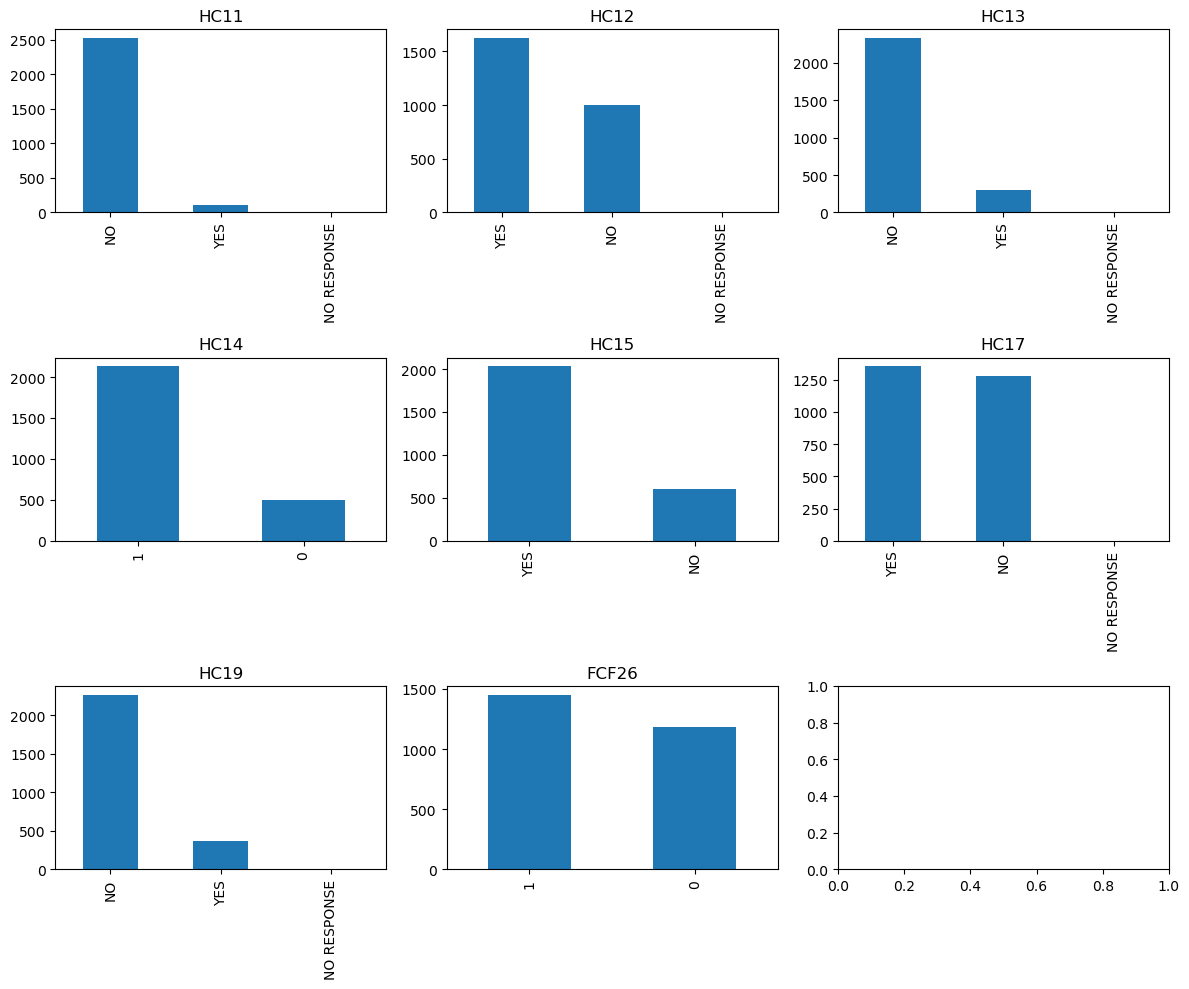

In [476]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(12, 10))  # adjust grid to fit your 9 columns
axes = axes.flatten()

for i, col in enumerate(df_hc_fcf26.columns):
    df_hc_fcf26[col].value_counts().plot(kind='bar', ax=axes[i], title=col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [477]:
df_hc_fcf26 = df_hc_fcf26.replace({'YES': 1, 'NO': 0, 'NO RESPONSE':0})
df_hc_fcf26.head()

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_81630/2004297019.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_hc_fcf26 = df_hc_fcf26.replace({'YES': 1, 'NO': 0, 'NO RESPONSE':0})


,HC11,HC12,HC13,HC14,HC15,HC17,HC19,FCF26
7403,0,1,0,1,1,1,0,0
4366,0,1,0,1,1,1,0,1
2173,0,0,0,1,1,0,0,0
12236,0,1,0,1,0,0,0,1
6724,1,1,1,0,0,1,1,1


In [478]:
df_hc_fcf26.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2633 entries, 7403 to 9430
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   HC11    2633 non-null   int64
 1   HC12    2633 non-null   int64
 2   HC13    2633 non-null   int64
 3   HC14    2633 non-null   int64
 4   HC15    2633 non-null   int64
 5   HC17    2633 non-null   int64
 6   HC19    2633 non-null   int64
 7   FCF26   2633 non-null   int64
dtypes: int64(8)
memory usage: 249.7 KB


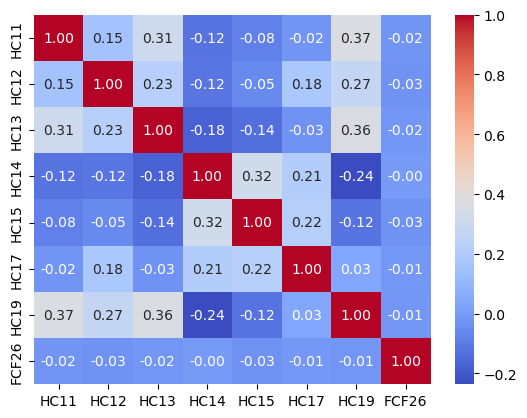

In [479]:
sns.heatmap(df_hc_fcf26.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()